In [63]:
%matplotlib inline

# basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from scipy.stats import linregress, spearmanr

# simulation modules
from social_network import SocialNetwork
from logic_matrix import LogicMatrix
from init_belief import InitialBelief
from functions import simulate, inject_kol

# metrics and tests
from metrics import compute_all_metrics, alignment_with_kol
from hypothesis_tests import run_alpha_alignment_test

# topology analysis
from topology_alignment_analysis import (
    run_topology_alpha_sweep,
    summarize_results,
    analyse_hypothesis_by_topology,
    plot_alpha_alignment,
    plot_topology_panels,
)

# Configs
## Output path

In [64]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_table(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved table to: {path}")
    return path


def save_current_figure(filename, dpi=300):
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure to: {path}")
    return path


## Simulation setup

In [65]:
AGENT_NUM=30
TOPIC_NUM=5
T=20
SEED=1942340
alpha_list = [0.3, 0.5, 0.7, 0.9]
models=["ER", "WS", "BA", "RR"]

# Treatments for controlled alpha list

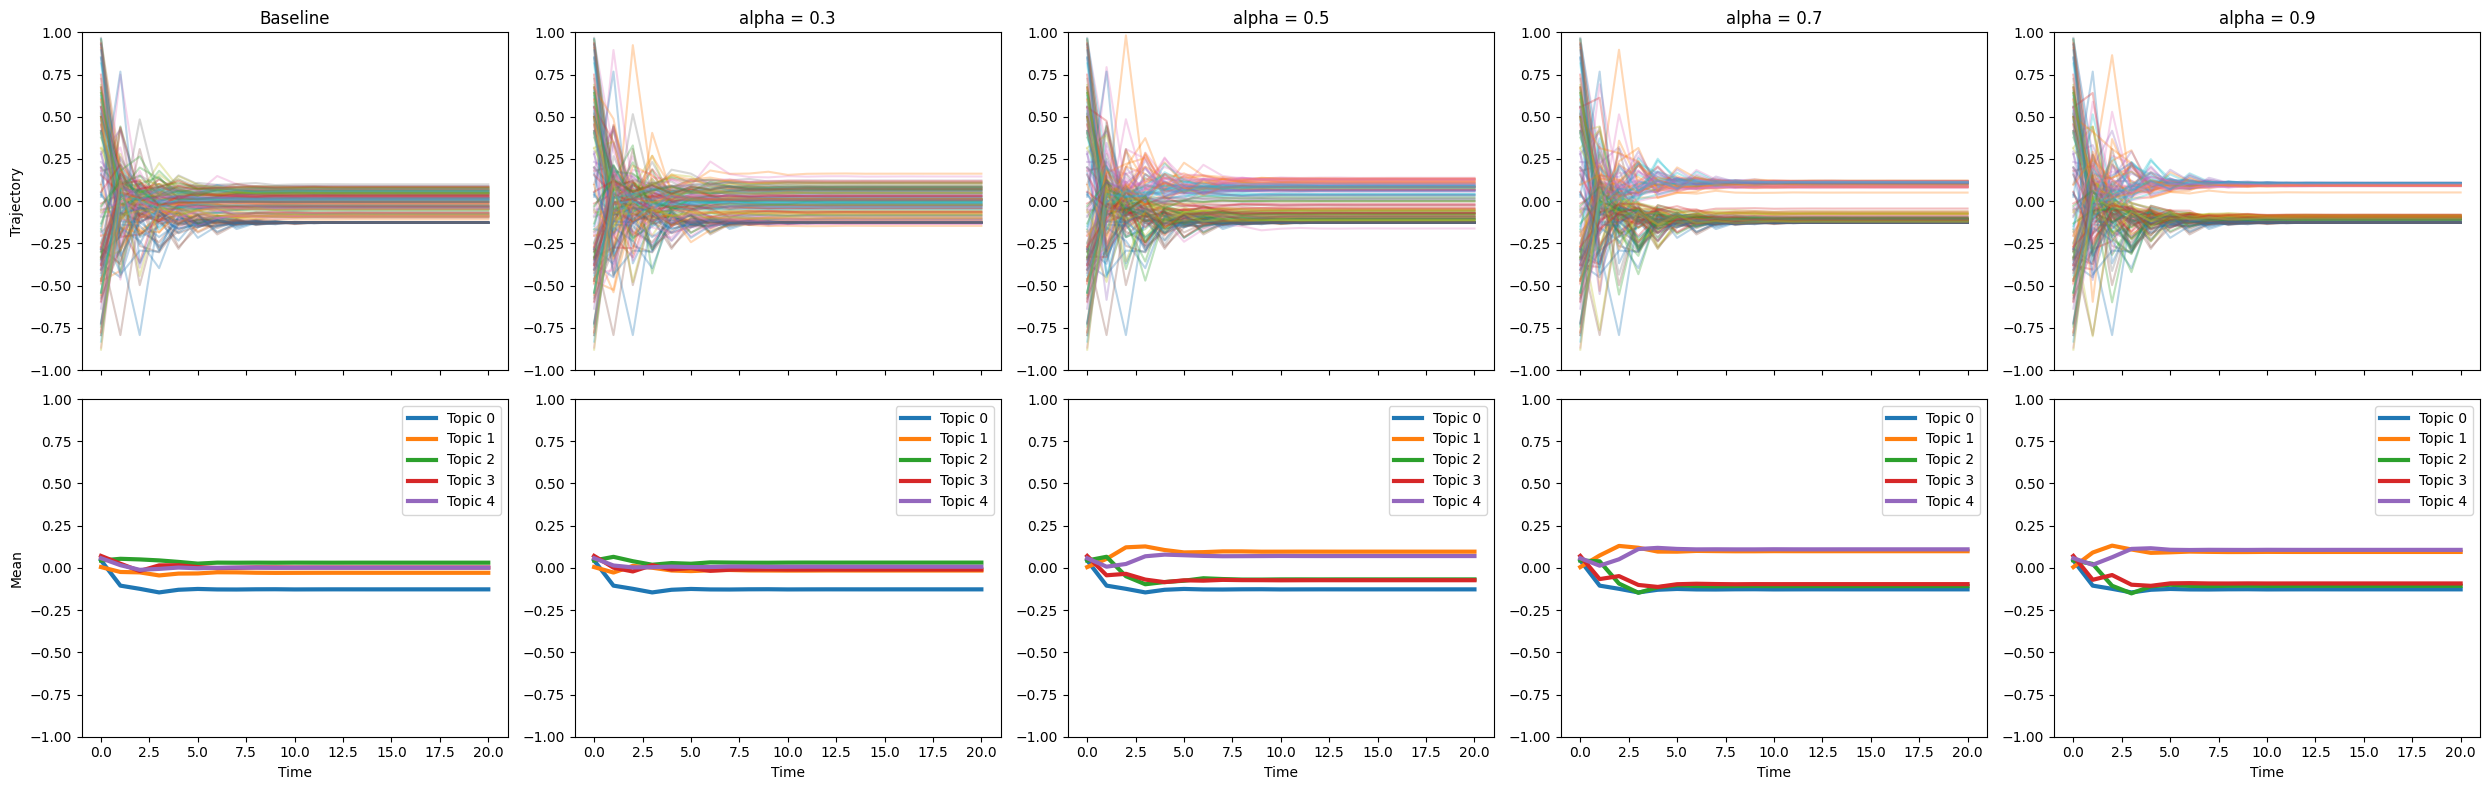

Saved figure to: outputs/controlled_alpha_trajectories.png
Saved table to: outputs/controlled_alpha_metrics.csv


,type,alpha,variance,mean,var,align_to_kol
0,baseline,NaN,0.010614,"[-0.13, -0.03, 0.03, 0.0, 0.0]",NaN,NaN
1,kol,0.3,NaN,"[-0.13, -0.02, 0.03, -0.01, 0.01]",0.019630,0.180181
2,kol,0.5,NaN,"[-0.13, 0.1, -0.07, -0.07, 0.07]",0.007113,0.088640
3,kol,0.7,NaN,"[-0.13, 0.1, -0.11, -0.1, 0.11]",0.000858,0.054516
4,kol,0.9,NaN,"[-0.13, 0.09, -0.11, -0.09, 0.11]",0.000137,0.043363


In [66]:
W = SocialNetwork(
    n=AGENT_NUM,
    random_beta=True,
    model="ER",
    seed=SEED
).generate()

W_matrix = W.W

C = LogicMatrix(
    n=AGENT_NUM,
    m=TOPIC_NUM,
    random_beta=True,
    seed=SEED
).generate()
C_base = C.C_base
C_tensor = np.array(C.C_list)   # shape: (n, m, m)

X0 = InitialBelief(
    n=AGENT_NUM,
    m=TOPIC_NUM,
    mode="uniform",
    seed=SEED
).generate()

X0_vector = X0.X0

traj = simulate(W_matrix, C_tensor, X0_vector, T=T)

traj_kol_list = []
for alpha in alpha_list:
    C_kol = inject_kol(C_tensor, C_base, alpha=alpha, kol_index=0)
    traj_kol = simulate(W_matrix, C_kol, X0_vector, T=T)
    traj_kol_list.append(traj_kol)

n = len(alpha_list)
fig, axes = plt.subplots(2, n+1, figsize=(5*(n+1), 8), sharex=True)

for i in range(traj.shape[1]):
    for k in range(TOPIC_NUM):
        axes[0, 0].plot(traj[:, i, k], alpha=0.3)

axes[0, 0].set_title("Baseline")
axes[0, 0].set_ylabel("Trajectory")

for idx, (traj_kol, alpha) in enumerate(zip(traj_kol_list, alpha_list)):
    ax = axes[0, idx+1]

    for i in range(traj_kol.shape[1]):
        for k in range(TOPIC_NUM):
            ax.plot(traj_kol[:, i, k], alpha=0.3)

    ax.set_title(f"alpha = {alpha}")

mean_base = traj.mean(axis=1)
for k in range(TOPIC_NUM):
    axes[1, 0].plot(mean_base[:, k], linewidth=3, label=f"Topic {k}")

axes[1, 0].set_ylabel("Mean")
axes[1, 0].set_xlabel("Time")
axes[1, 0].legend()

for idx, (traj_kol, alpha) in enumerate(zip(traj_kol_list, alpha_list)):
    ax = axes[1, idx+1]

    mean = traj_kol.mean(axis=1)
    for k in range(TOPIC_NUM):
        ax.plot(mean[:, k], linewidth=3, label=f"Topic {k}")

    ax.set_xlabel("Time")
    ax.legend()

for ax in axes.flatten():
    ax.set_ylim(-1, 1)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "controlled_alpha_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {OUTPUT_DIR / 'controlled_alpha_trajectories.png'}")

m_base = compute_all_metrics(traj)

rows = [
    {
        "type": "baseline",
        "alpha": None,
        "variance": m_base["final_variance"],
        "mean": m_base["final_mean"]
    }
]

m_kol_list = [
    compute_all_metrics(traj_kol, kol_index=0)
    for traj_kol in traj_kol_list
]

df = pd.DataFrame(rows + [
    {
        "type": "kol",
        "alpha": alpha,
        "var": m_kol["final_variance"],
        "align_to_kol": m_kol["final_alignment"],
        "mean": m_kol["final_mean"]
    }
    for alpha, m_kol in zip(alpha_list, m_kol_list)
])

df["mean"] = df["mean"].apply(lambda x: np.round(x, 2))
save_table(df, "controlled_alpha_metrics.csv")
df



# Treatments for controlled topologies

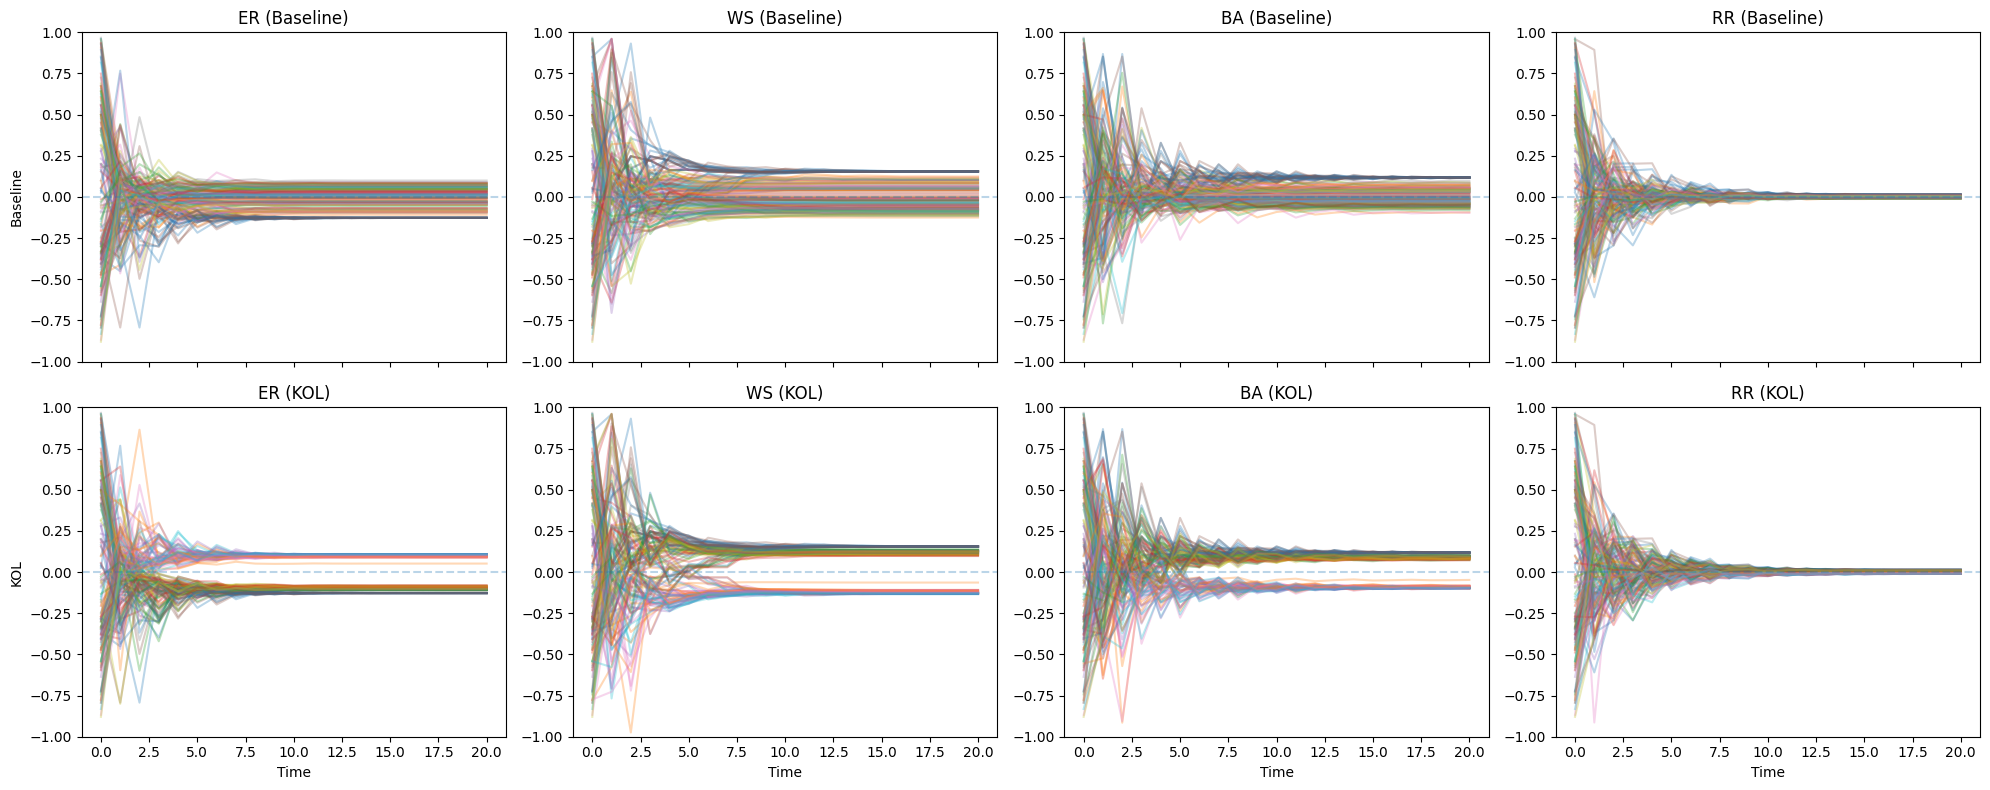

Saved figure to: outputs/controlled_topology_trajectories.png
Saved table to: outputs/controlled_topology_metrics.csv


,model,var_base,var_kol,delta_var,align_to_kol,mean_base,mean_kol
0,ER,0.010614,0.000137,0.010478,0.043363,"[-0.13, -0.03, 0.03, 0.0, 0.0]","[-0.13, 0.09, -0.11, -0.09, 0.11]"
1,WS,0.016807,0.000220,0.016586,0.052902,"[0.16, 0.03, -0.04, -0.0, -0.0]","[0.16, -0.12, 0.13, 0.11, -0.13]"
2,BA,0.008491,0.000184,0.008308,0.042125,"[0.12, 0.02, -0.02, 0.0, -0.0]","[0.12, -0.09, 0.1, 0.09, -0.1]"
3,RR,0.000105,0.000002,0.000104,0.004579,"[0.01, 0.0, -0.0, -0.0, -0.0]","[0.01, -0.01, 0.01, 0.01, -0.01]"


In [67]:
C = LogicMatrix(
    n=AGENT_NUM,
    m=TOPIC_NUM,
    random_beta=True,
    seed=SEED
).generate()

C_base = C.C_base
C_tensor = np.array(C.C_list)

X0 = InitialBelief(
    n=AGENT_NUM,
    m=TOPIC_NUM,
    mode="uniform",
    seed=SEED
).generate()

X0_vector = X0.X0

traj_base_list = []
traj_kol_list = []

C_kol = inject_kol(C_tensor, C_base, alpha=alpha, kol_index=0)
for model in models:
    W = SocialNetwork(
        n=AGENT_NUM,
        model=model,
        random_beta=True,
        seed=SEED
    ).generate()

    W_matrix = W.W
    traj = simulate(W_matrix, C_tensor, X0_vector, T=T)
    traj_kol = simulate(W_matrix, C_kol, X0_vector, T=T)

    traj_base_list.append(traj)
    traj_kol_list.append(traj_kol)

n = len(models)
fig, axes = plt.subplots(2, n, figsize=(5*n, 8), sharex=True)

for idx, traj in enumerate(traj_base_list):
    ax = axes[0, idx]

    for i in range(traj.shape[1]):
        for k in range(TOPIC_NUM):
            ax.plot(traj[:, i, k], alpha=0.3)

    ax.set_title(f"{models[idx]} (Baseline)")
    ax.set_ylim(-1, 1)

axes[0, 0].set_ylabel("Baseline")

for idx, traj in enumerate(traj_kol_list):
    ax = axes[1, idx]

    for i in range(traj.shape[1]):
        for k in range(TOPIC_NUM):
            ax.plot(traj[:, i, k], alpha=0.3)

    ax.set_title(f"{models[idx]} (KOL)")
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Time")

axes[1, 0].set_ylabel("KOL")

for ax in axes.flatten():
    ax.axhline(0, linestyle="--", alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "controlled_topology_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {OUTPUT_DIR / 'controlled_topology_trajectories.png'}")

rows = []

for model, traj, traj_kol in zip(models, traj_base_list, traj_kol_list):
    m_base = compute_all_metrics(traj)
    m_kol = compute_all_metrics(traj_kol, kol_index=0)

    rows.append({
        "model": model,
        "var_base": m_base["final_variance"],
        "var_kol": m_kol["final_variance"],
        "delta_var": m_base["final_variance"] - m_kol["final_variance"],
        "align_to_kol": m_kol["final_alignment"],
        "mean_base": m_base["final_mean"],
        "mean_kol": m_kol["final_mean"]
    })

df = pd.DataFrame(rows)
df["mean_base"] = df["mean_base"].apply(lambda x: np.round(x, 2))
df["mean_kol"] = df["mean_kol"].apply(lambda x: np.round(x, 2))
save_table(df, "controlled_topology_metrics.csv")
df



# Hypothesis test

Let `alignment(alpha)` denote the final alignment distance to the KOL under a given value of `alpha`.

$H_0$: $\mathbb{E}[\text{alignment}(\alpha_{\text{high}}) - \text{alignment}(\alpha_{\text{low}})] = 0$

$H_1$: $\mathbb{E}[\text{alignment}(\alpha_{\text{high}}) - \text{alignment}(\alpha_{\text{low}})] < 0$


In [68]:


result = run_alpha_alignment_test(
    agent_num=30,
    topic_num=3,
    T=20,
    alpha_low=0.3,
    alpha_high=0.9,
    metric_name="final_alignment",
    n_replications=100,
    alternative="less",
    network_model="ER",   # 建议先固定一个拓扑
    belief_mode="uniform",
    random_beta=True,
    kol_index=0,
    base_seed=1942340,
    n_resamples=5000,
)

result.summary()


{'metric_name': 'final_alignment',
 'alternative': 'less',
 'n_pairs': 100,
 'baseline_mean': 0.2519301809338595,
 'treatment_mean': 0.11723890403905311,
 'observed_effect': -0.1346912768948064,
 'p_value': 0.0001999600079984003,
 'p_value_display': '2.000e-04',
 'ci_low': -0.15654824081550966,
 'ci_high': -0.11184623445100236}

# Research for alpha influence different topologies

,topology,alpha,n,mean_final_alignment,std_final_alignment,ci95_final_alignment
0,BA,0.3,50,0.303450,0.178926,0.049596
1,BA,0.5,50,0.241535,0.147841,0.040980
2,BA,0.7,50,0.137668,0.086932,0.024096
3,BA,0.9,50,0.109375,0.085529,0.023707
4,ER,0.3,50,0.318101,0.183112,0.050756
5,ER,0.5,50,0.256701,0.157988,0.043792
6,ER,0.7,50,0.148603,0.092325,0.025591
7,ER,0.9,50,0.126074,0.111911,0.031020
8,RR,0.3,50,0.320367,0.220769,0.061194
9,RR,0.5,50,0.254437,0.170279,0.047199


,topology,slope,intercept,r_value,r_squared,p_value_linear,spearman_rho,p_value_spearman,supports_hypothesis
0,BA,-0.343047,0.403835,-0.506129,0.256167,2.083469e-14,-0.523634,1.777406e-15,True
1,ER,-0.342089,0.417623,-0.477607,0.228108,8.610193e-13,-0.499001,5.455717e-14,True
2,RR,-0.346158,0.420631,-0.438466,0.192252,8.370016e-11,-0.481340,5.393514e-13,True
3,WS,-0.344275,0.433611,-0.407763,0.166271,2.059844e-09,-0.468172,2.738380e-12,True


Saved table to: outputs/topology_replication_results.csv
Saved table to: outputs/topology_summary_results.csv
Saved table to: outputs/topology_hypothesis_tests.csv


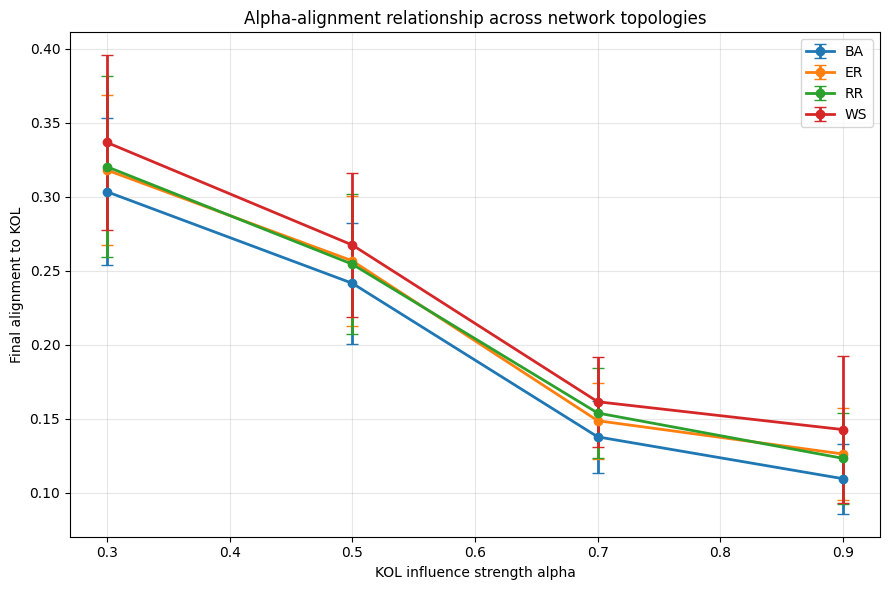

Saved figure to: outputs/topology_alpha_alignment_all.png


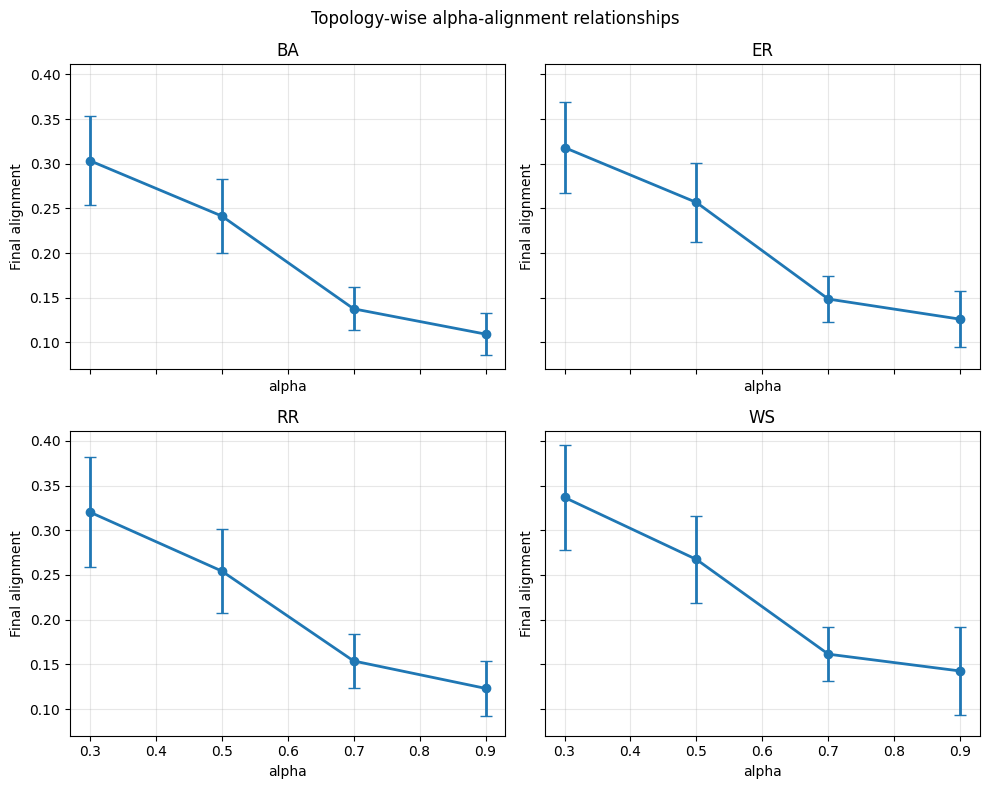

Saved figure to: outputs/topology_alpha_alignment_panels.png


In [69]:
rows = run_topology_alpha_sweep(
    agent_num=AGENT_NUM,
    topic_num=TOPIC_NUM,
    T=T,
    alpha_values=alpha_list,
    topologies=models,
    n_replications=50,
    belief_mode="uniform",
    random_beta=True,
    kol_index=0,
    base_seed=SEED,
)

summary_rows = summarize_results(rows)
trend_rows = analyse_hypothesis_by_topology(rows)

df_rep = pd.DataFrame(rows)
df_summary = pd.DataFrame(summary_rows).sort_values(["topology", "alpha"]).reset_index(drop=True)
df_trend = pd.DataFrame(trend_rows).sort_values("topology").reset_index(drop=True)

display(df_summary)
display(df_trend)

save_table(df_rep, "topology_replication_results.csv")
save_table(df_summary, "topology_summary_results.csv")
save_table(df_trend, "topology_hypothesis_tests.csv")

plot_alpha_alignment(
    summary_rows,
    output_path=OUTPUT_DIR / "topology_alpha_alignment_all.png",
    show=True,
)
print(f"Saved figure to: {OUTPUT_DIR / 'topology_alpha_alignment_all.png'}")

plot_topology_panels(
    summary_rows,
    output_path=OUTPUT_DIR / "topology_alpha_alignment_panels.png",
    show=True,
)
print(f"Saved figure to: {OUTPUT_DIR / 'topology_alpha_alignment_panels.png'}")



# Effect of Alpha Under Different Heterogeneities of the C Matrix

In [70]:

def run_beta_alpha_sweep(
    agent_num,
    topic_num,
    T,
    alpha_values,
    beta_settings,
    topology="ER",
    n_replications=50,
    belief_mode="uniform",
    random_network_beta=True,
    kol_index=0,
    base_seed=1942340,
):
    rows = []

    for beta_name, beta_params in beta_settings.items():
        for rep in range(n_replications):
            seed = base_seed + rep

            W = SocialNetwork(
                n=agent_num,
                model=topology,
                random_beta=random_network_beta,
                seed=seed,
            ).generate().W

            logic = LogicMatrix(
                n=agent_num,
                m=topic_num,
                beta_params=beta_params,
                random_beta=False,
                seed=seed,
            ).generate()

            C_tensor = np.asarray(logic.C_list)
            C_base = logic.C_base

            X0 = InitialBelief(
                n=agent_num,
                m=topic_num,
                mode=belief_mode,
                seed=seed,
            ).generate().X0

            for alpha in alpha_values:
                C_kol = inject_kol(C_tensor, C_base, alpha=alpha, kol_index=kol_index)
                traj = simulate(W, C_kol, X0, T=T)
                alignment_traj = alignment_with_kol(traj, kol_index=kol_index)

                rows.append(
                    {
                        "topology": topology,
                        "beta_level": beta_name,
                        "beta_a": beta_params[0],
                        "beta_b": beta_params[1],
                        "replication": rep,
                        "seed": seed,
                        "alpha": float(alpha),
                        "final_alignment": float(alignment_traj[-1]),
                        "mean_alignment": float(np.mean(alignment_traj)),
                    }
                )

    return rows


def summarize_beta_alpha_results(rows):
    grouped = {}
    for row in rows:
        key = (row["beta_level"], row["alpha"])
        grouped.setdefault(key, []).append(row["final_alignment"])

    summary_rows = []
    for (beta_level, alpha), values in sorted(grouped.items(), key=lambda x: (x[0][0], x[0][1])):
        values = np.asarray(values, dtype=float)
        mean = float(values.mean())
        std = float(values.std(ddof=1)) if len(values) > 1 else 0.0
        sem = std / np.sqrt(len(values)) if len(values) > 0 else 0.0
        ci95 = 1.96 * sem

        summary_rows.append(
            {
                "beta_level": beta_level,
                "alpha": alpha,
                "n": int(len(values)),
                "mean_final_alignment": mean,
                "std_final_alignment": std,
                "ci95_final_alignment": float(ci95),
            }
        )

    return summary_rows


def plot_beta_alpha_relationship(summary_rows, output_path=None, show=True):
    plt.figure(figsize=(9, 6))

    beta_groups = {}
    for row in summary_rows:
        beta_groups.setdefault(row["beta_level"], []).append(row)

    for beta_level, items in sorted(beta_groups.items()):
        items = sorted(items, key=lambda x: x["alpha"])
        alpha = [x["alpha"] for x in items]
        mean_alignment = [x["mean_final_alignment"] for x in items]
        ci95 = [x["ci95_final_alignment"] for x in items]

        plt.errorbar(
            alpha,
            mean_alignment,
            yerr=ci95,
            marker="o",
            linewidth=2,
            capsize=4,
            label=beta_level,
        )

    plt.xlabel("KOL influence strength alpha")
    plt.ylabel("Final alignment to KOL")
    plt.title("Alpha-alignment relationship under different beta levels of C")
    plt.grid(alpha=0.3)
    plt.legend(title="Beta level")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()


def plot_beta_alpha_panels(summary_rows, output_path=None, show=True):
    beta_groups = {}
    for row in summary_rows:
        beta_groups.setdefault(row["beta_level"], []).append(row)

    beta_levels = sorted(beta_groups.keys())
    fig, axes = plt.subplots(1, len(beta_levels), figsize=(5 * len(beta_levels), 4), sharey=True)

    if len(beta_levels) == 1:
        axes = [axes]

    for ax, beta_level in zip(axes, beta_levels):
        items = sorted(beta_groups[beta_level], key=lambda x: x["alpha"])
        alpha = [x["alpha"] for x in items]
        mean_alignment = [x["mean_final_alignment"] for x in items]
        ci95 = [x["ci95_final_alignment"] for x in items]

        ax.errorbar(
            alpha,
            mean_alignment,
            yerr=ci95,
            marker="o",
            linewidth=2,
            capsize=4,
        )
        ax.set_title(beta_level)
        ax.set_xlabel("alpha")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Final alignment to KOL")
    fig.suptitle("Topology fixed, varying beta levels of C", y=1.02)
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)



,beta_level,alpha,n,mean_final_alignment,std_final_alignment,ci95_final_alignment
0,High heterogeneity,0.0,50,0.380516,0.190087,0.052689
1,High heterogeneity,0.3,50,0.308857,0.150180,0.041628
2,High heterogeneity,0.5,50,0.237762,0.115877,0.032119
3,High heterogeneity,0.7,50,0.155833,0.082779,0.022945
4,High heterogeneity,0.9,50,0.139027,0.120364,0.033363
5,High heterogeneity,1.0,50,0.168547,0.251452,0.069699
6,Low heterogeneity,0.0,50,0.336540,0.156740,0.043446
7,Low heterogeneity,0.3,50,0.300772,0.141057,0.039099
8,Low heterogeneity,0.5,50,0.237551,0.108547,0.030088
9,Low heterogeneity,0.7,50,0.144842,0.070446,0.019527


Saved table to: outputs/beta_replication_results.csv
Saved table to: outputs/beta_summary_results.csv


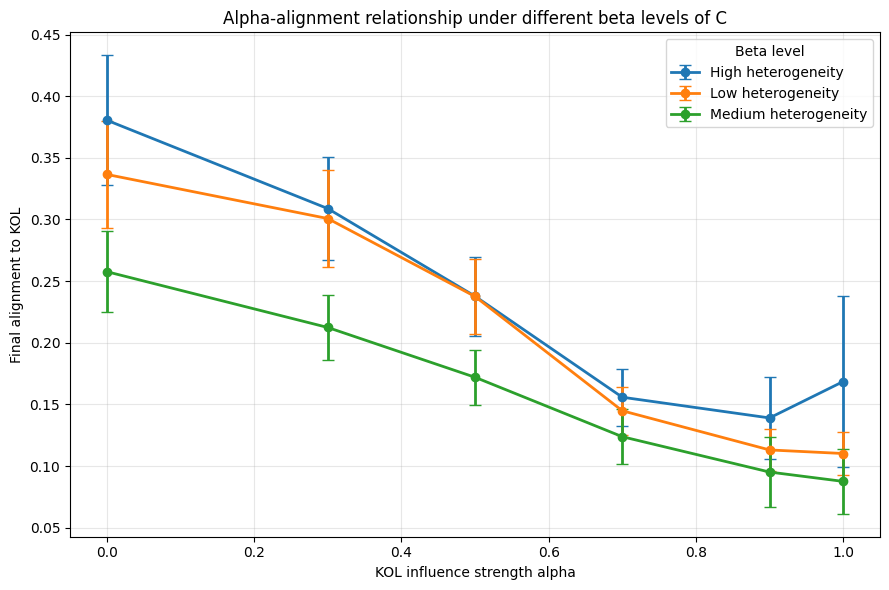

Saved figure to: outputs/beta_alpha_alignment_all.png


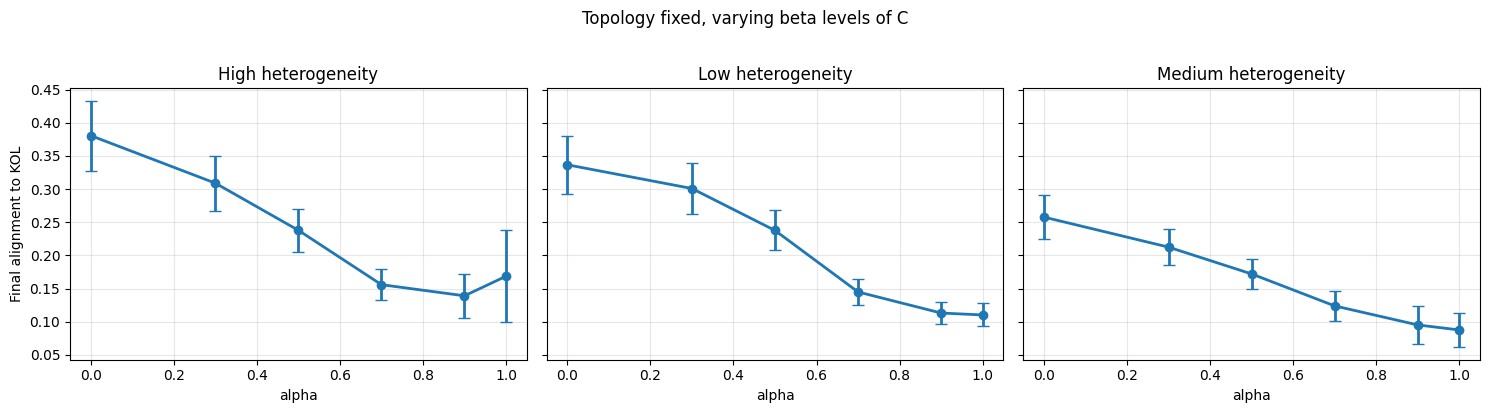

Saved figure to: outputs/beta_alpha_alignment_panels.png


In [71]:
AGENT_NUM = 30
TOPIC_NUM = 5
T = 20
SEED = 1942340

alpha_list = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]

beta_settings = {
    "Low heterogeneity": (5, 5),
    "Medium heterogeneity": (2, 5),
    "High heterogeneity": (0.5, 0.5),
}

beta_rows = run_beta_alpha_sweep(
    agent_num=AGENT_NUM,
    topic_num=TOPIC_NUM,
    T=T,
    alpha_values=alpha_list,
    beta_settings=beta_settings,
    topology="ER",
    n_replications=50,
    belief_mode="uniform",
    random_network_beta=True,
    kol_index=0,
    base_seed=SEED,
)

beta_summary_rows = summarize_beta_alpha_results(beta_rows)

df_beta_rep = pd.DataFrame(beta_rows)
df_beta_summary = pd.DataFrame(beta_summary_rows)

display(df_beta_summary)

save_table(df_beta_rep, "beta_replication_results.csv")
save_table(df_beta_summary, "beta_summary_results.csv")

plot_beta_alpha_relationship(
    beta_summary_rows,
    output_path=OUTPUT_DIR / "beta_alpha_alignment_all.png",
    show=True,
)
print(f"Saved figure to: {OUTPUT_DIR / 'beta_alpha_alignment_all.png'}")

plot_beta_alpha_panels(
    beta_summary_rows,
    output_path=OUTPUT_DIR / "beta_alpha_alignment_panels.png",
    show=True,
)
print(f"Saved figure to: {OUTPUT_DIR / 'beta_alpha_alignment_panels.png'}")



In [72]:
trend_rows = []
for beta_level, group in df_beta_rep.groupby("beta_level"):
    lin = linregress(group["alpha"], group["final_alignment"])
    spear = spearmanr(group["alpha"], group["final_alignment"])
    trend_rows.append(
        {
            "beta_level": beta_level,
            "slope": lin.slope,
            "p_value_linear": lin.pvalue,
            "spearman_rho": spear.statistic,
            "p_value_spearman": spear.pvalue,
        }
    )

df_beta_trend = pd.DataFrame(trend_rows)
display(df_beta_trend)
save_table(df_beta_trend, "beta_hypothesis_tests.csv")



,beta_level,slope,p_value_linear,spearman_rho,p_value_spearman
0,High heterogeneity,-0.243478,4.233528e-17,-0.542705,2.238467e-24
1,Low heterogeneity,-0.255143,6.236331e-35,-0.618408,4.822058e-33
2,Medium heterogeneity,-0.179380,1.829802e-24,-0.591611,1.031539e-29


Saved table to: outputs/beta_hypothesis_tests.csv


PosixPath('outputs/beta_hypothesis_tests.csv')